# Lightweight IDS Using Machine Learning for IoT Devices
## Notebook 03: Model Training and Resource Efficiency Evaluation

**Author:** Mimi Nguyet Mi Taylor  
**Programme:** MSc Computer Science, Birkbeck, University of London  
**Supervisor:** Professor Paul Yoo

---

### About this notebook
This notebook trains five traditional classifiers alongside a minimal
Multilayer Perceptron (MLP) baseline on the preprocessed data from
Notebook 02, and measures resource efficiency for each. Classifiers are
given the preprocessing they require: Decision Tree, Random Forest and
Naive Bayes use the unscaled data, while Logistic Regression, KNN and
MLP use the StandardScaler data, as they are sensitive to feature scale.

Classifiers trained:
1. Decision Tree
2. Random Forest
3. Naive Bayes
4. Logistic Regression 
5. K-Nearest Neighbour (KNN)
6. Multilayer Perceptron (MLP) as a minimal baseline

Resource efficiency metrics recorded for each classifier:
- Training time (seconds)
- Total batch inference time (seconds) and throughput (records/second)
- Single-record latency (milliseconds), mean, median and std over 1000 runs
- Memory usage (MB)
- Model size (KB)

The ranking of the two top models is then checked with 5-fold stratified
cross-validation, with SMOTE-ENN applied inside each fold to avoid leakage.

### Input
- X_train_resampled.pkl
- y_train_resampled.pkl
- X_test.pkl
- y_test.pkl
- X_train_scaled.pkl
- X_test_scaled.pkl
- X_train_unresampled.pkl
- y_train_unresampled.pkl

### Output
- One saved model per classifier (.pkl)
- results_accuracy.csv
- results_resources.csv
- results_cross_validation.csv
- results_cv_fold_scores.csv

In [1]:
# Import all libraries needed for this notebook.
# sklearn: all five traditional classifiers and MLP
# time: measuring training and inference time
# tracemalloc: measuring peak memory usage during inference
# joblib: saving models and loading preprocessed data
# pandas/numpy: data handling
# os: file paths

import pandas as pd
import numpy as np
import time
import tracemalloc
import joblib
import os

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

RANDOM_STATE = 42
OUTPUT_DIR = os.path.expanduser("~/IDS_PROJECT_REPORT/")

print("All imports successful.")

All imports successful.


In [2]:
# Load the preprocessed data saved by Notebook 02.
# We load both the unscaled and the scaled versions of the data.
#
# Unscaled data (X_train, X_test) is used by the scale-invariant
# classifiers: Decision Tree, Random Forest and Naive Bayes.
#
# Scaled data (X_train_scaled, X_test_scaled) is used by the
# scale-sensitive classifiers: Logistic Regression, KNN and MLP.
#
# y_train and y_test are the same labels for both, because scaling
# only transforms the features, never the labels.

X_train = joblib.load(OUTPUT_DIR + "X_train_resampled.pkl")
y_train = joblib.load(OUTPUT_DIR + "y_train_resampled.pkl")
X_test  = joblib.load(OUTPUT_DIR + "X_test.pkl")
y_test  = joblib.load(OUTPUT_DIR + "y_test.pkl")

X_train_scaled = joblib.load(OUTPUT_DIR + "X_train_scaled.pkl")
X_test_scaled  = joblib.load(OUTPUT_DIR + "X_test_scaled.pkl")

print("Data loaded.")
print(f"  Unscaled training set: {X_train.shape}")
print(f"  Scaled training set:   {X_train_scaled.shape}")
print(f"  Test set:              {X_test.shape}")
print(f"\nTraining classes: {pd.Series(y_train).value_counts().to_dict()}")

Data loaded.
  Unscaled training set: (2273555, 13)
  Scaled training set:   (2273555, 13)
  Test set:              (219362, 13)

Training classes: {'Mirai': 340044, 'Brute Force': 329593, 'Web-based': 323178, 'Spoofing': 312879, 'Reconnaissance': 307792, 'Benign': 295385, 'DDoS': 195702, 'DoS': 168982}


In [3]:
# This function trains a classifier and measures resource efficiency.
# Metrics recorded:
#   - Training time (seconds)
#   - Model size (KB) on disk
#   - Memory usage (MB) during batch inference
#   - Total batch inference time (seconds) for the whole test set
#   - Throughput (records per second) in batch mode
#   - Single-record latency (milliseconds), measured one record at a
#     time and repeated 1000 times, reported as mean, median and std
#
# Why three inference measurements instead of one:
# A single "ms per record" figure is only the batch time divided by the
# number of records. It hides how the model actually behaves. Batch time
# and throughput describe bulk processing. Single-record latency describes
# real-time detection, where records arrive one at a time. 
# These can differ on some models, so they are reported separately.

SINGLE_RECORD_REPEATS = 1000

def train_and_evaluate(name, clf, X_train, y_train, X_test, y_test, output_dir):
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print(f"{'='*50}")

    # Training time
    start = time.perf_counter()
    clf.fit(X_train, y_train)
    training_time = time.perf_counter() - start
    print(f"Training time: {training_time:.2f} seconds")

    # Save model and measure model size on disk
    model_path = output_dir + f"model_{name.replace(' ', '_')}.pkl"
    joblib.dump(clf, model_path)
    model_size_kb = os.path.getsize(model_path) / 1024
    print(f"Model size: {model_size_kb:.2f} KB")

    # Batch inference: total time and throughput.
    #    Clean run with no profiler, so the timing is not inflated.
    start = time.perf_counter()
    y_pred = clf.predict(X_test)
    total_batch_time = time.perf_counter() - start
    throughput = len(X_test) / total_batch_time  # records per second
    print(f"Total batch time: {total_batch_time:.4f} s for {len(X_test):,} records")
    print(f"Throughput: {throughput:,.0f} records/second")

    # Memory usage during batch inference.
    #    Separate run under tracemalloc, so profiler overhead does not
    #    affect the timing measured in step 3.
    tracemalloc.start()
    clf.predict(X_test)
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_memory_mb = peak_memory / (1024 * 1024)
    print(f"Peak memory usage: {peak_memory_mb:.2f} MB")

    # Single-record latency: predict one record at a time, repeated,
    #    to reflect real-time detection where records arrive individually.
    #    The single record is taken in the same data type as X_test
    #    (DataFrame or array) to avoid feature-name warnings.
    if hasattr(X_test, "iloc"):
        single_record = X_test.iloc[0:1]
    else:
        single_record = X_test[0:1]

    single_latencies = []
    for _ in range(SINGLE_RECORD_REPEATS):
        start = time.perf_counter()
        clf.predict(single_record)
        single_latencies.append(time.perf_counter() - start)

    single_latencies = np.array(single_latencies) * 1000.0  # to milliseconds
    latency_mean = single_latencies.mean()
    latency_median = np.median(single_latencies)
    latency_std = single_latencies.std()
    print(f"Single-record latency over {SINGLE_RECORD_REPEATS} runs: "
          f"mean {latency_mean:.4f} ms, median {latency_median:.4f} ms, "
          f"std {latency_std:.4f} ms")

    # Accuracy metrics
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return {
        'Classifier': name,
        'Training Time (s)': round(training_time, 2),
        'Total Batch Time (s)': round(total_batch_time, 4),
        'Throughput (rec/s)': round(throughput, 0),
        'Latency mean (ms)': round(latency_mean, 4),
        'Latency median (ms)': round(latency_median, 4),
        'Latency std (ms)': round(latency_std, 4),
        'Memory Usage (MB)': round(peak_memory_mb, 2),
        'Model Size (KB)': round(model_size_kb, 2)
    }, y_pred

print("Function defined successfully.")

Function defined successfully.


In [4]:
# Define the five traditional classifiers and the MLP baseline.
# Every hyperparameter is written out explicitly for reproducibility.
# If a value below matches the current default, it is still stated in full, so the
# exact configuration is recorded and does not change if a future
# library version changes its defaults.
#
# A fixed random_state is set wherever the estimator supports it.
#
# Each classifier carries a "scaling" tag:
#   "unscaled" -> trained on the raw SMOTE-ENN data (X_train)
#   "scaled"   -> trained on the StandardScaler data (X_train_scaled)
# Decision Tree, Random Forest and Naive Bayes are scale-invariant.
# Logistic Regression, KNN and MLP are scale-sensitive.

classifiers = [
    (
        "Decision Tree",
        "unscaled",
        DecisionTreeClassifier(
            criterion="gini",        # split quality measure
            max_depth=None,          # grow until leaves are pure (no depth limit)
            min_samples_split=2,     # minimum samples needed to split a node
            min_samples_leaf=1,      # minimum samples allowed in a leaf
            random_state=RANDOM_STATE
        )
    ),
    (
        "Random Forest",
        "unscaled",
        RandomForestClassifier(
            n_estimators=100,        # number of trees in the forest
            criterion="gini",        # split quality measure
            max_depth=None,          # each tree grows until its leaves are pure
            max_features="sqrt",     # features considered at each split
            random_state=RANDOM_STATE,
            n_jobs=-1                # use all CPU cores
        )
    ),
    (
        "Naive Bayes",
        "unscaled",
        # Gaussian variant: assumes each feature follows a normal
        # distribution within each class. Chosen because all 13
        # selected features are continuous numeric values.
        GaussianNB(
            var_smoothing=1e-9       # numerical stability term
        )
    ),
    (
        "Logistic Regression",
        "scaled",
        LogisticRegression(
            solver="lbfgs",          # optimiser used for multinomial problems
            l1_ratio=0,              # ridge (L2) regularisation
            C=1.0,                   # inverse of regularisation strength
            max_iter=1000,           # iteration limit
            random_state=RANDOM_STATE
        )
    ),
    (
        "KNN",
        "scaled",
        KNeighborsClassifier(
            n_neighbors=5,           # number of neighbours voting on each prediction
            weights="uniform",       # all neighbours weighted equally
            metric="minkowski",      # distance metric
            p=2,                     # p=2 makes this Euclidean distance
            n_jobs=-1
        )
    ),
    (
        "MLP",
        "scaled",
        MLPClassifier(
            hidden_layer_sizes=(100,),  # one hidden layer of 100 neurons
            activation="relu",          # rectified linear activation
            solver="adam",              # stochastic gradient-based optimiser
            alpha=0.0001,               # L2 regularisation term
            max_iter=500,               # raised to 500, high enough for the optimiser to converge (see report)
            random_state=RANDOM_STATE
        )
    ),
]

print(f"Defined {len(classifiers)} classifiers:")
for name, scaling, clf in classifiers:
    print(f"  {name:<22} ({scaling})")

Defined 6 classifiers:
  Decision Tree          (unscaled)
  Random Forest          (unscaled)
  Naive Bayes            (unscaled)
  Logistic Regression    (scaled)
  KNN                    (scaled)
  MLP                    (scaled)


In [5]:
# Train and evaluate all classifiers.
# For each classifier we read its scaling tag and hand it the matching
# data: unscaled classifiers get X_train and X_test, scaled classifiers
# get X_train_scaled and X_test_scaled. The labels are identical either way.
#
# Results are collected into two structures:
# - resource_results: training time, inference timing, memory, model size
# - all_predictions: predicted labels per classifier, for accuracy analysis

resource_results = []
all_predictions = {}

for name, scaling, clf in classifiers:
    if scaling == "scaled":
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test

    print(f"\n>>> {name}  (using {scaling} data)")

    metrics, y_pred = train_and_evaluate(
        name, clf, X_tr, y_train, X_te, y_test, OUTPUT_DIR
    )
    resource_results.append(metrics)
    all_predictions[name] = y_pred

print("\n" + "="*50)
print("All classifiers trained and evaluated.")
print("="*50)


>>> Decision Tree  (using unscaled data)

Training: Decision Tree
Training time: 29.00 seconds
Model size: 14391.52 KB
Total batch time: 0.0300 s for 219,362 records
Throughput: 7,313,976 records/second
Peak memory usage: 32.64 MB
Single-record latency over 1000 runs: mean 0.2042 ms, median 0.2022 ms, std 0.0100 ms

Classification Report:
                precision    recall  f1-score   support

        Benign       0.74      0.73      0.73      7003
   Brute Force       0.04      0.07      0.05        83
          DDoS       0.87      0.75      0.80    146204
           DoS       0.40      0.60      0.48     41744
         Mirai       0.99      1.00      0.99     16763
Reconnaissance       0.63      0.62      0.63      4402
      Spoofing       0.79      0.79      0.79      3004
     Web-based       0.07      0.14      0.10       159

      accuracy                           0.74    219362
     macro avg       0.57      0.59      0.57    219362
  weighted avg       0.78      0.74     

In [6]:
# Save resource efficiency results to CSV
df_resources = pd.DataFrame(resource_results)
df_resources.to_csv(OUTPUT_DIR + "results_resources.csv", index=False)

print("Resource efficiency results saved.")
print(df_resources.to_string(index=False))

Resource efficiency results saved.
         Classifier  Training Time (s)  Total Batch Time (s)  Throughput (rec/s)  Latency mean (ms)  Latency median (ms)  Latency std (ms)  Memory Usage (MB)  Model Size (KB)
      Decision Tree              29.00                0.0300           7313976.0             0.2042               0.2022            0.0100              32.64         14391.52
      Random Forest             101.05                0.5570            393854.0            13.1320              13.2981            0.7405             116.44       1557178.52
        Naive Bayes               1.95                0.0229           9577889.0             0.2567               0.2536            0.0085              76.99             3.27
Logistic Regression              68.41                0.0038          58446519.0             0.0328               0.0327            0.0018              26.84             1.90
                KNN               3.89                3.7288             58829.0          

In [7]:
# Save accuracy results to CSV.
# Saving the full classification report for each classifier
# so that we have per-class precision, recall and F1-score on record.

accuracy_rows = []

for name, y_pred in all_predictions.items():
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, y_pred, labels=sorted(y_test.unique())
    )
    for i, label in enumerate(sorted(y_test.unique())):
        accuracy_rows.append({
            'Classifier': name,
            'Attack Category': label,
            'Precision': round(precision[i], 4),
            'Recall': round(recall[i], 4),
            'F1-Score': round(f1[i], 4),
            'Support': support[i]
        })

df_accuracy = pd.DataFrame(accuracy_rows)
df_accuracy.to_csv(OUTPUT_DIR + "results_accuracy.csv", index=False)

print("Accuracy results saved.")
print(df_accuracy.to_string(index=False))

Accuracy results saved.
         Classifier Attack Category  Precision  Recall  F1-Score  Support
      Decision Tree          Benign     0.7416  0.7283    0.7349     7003
      Decision Tree     Brute Force     0.0429  0.0723    0.0538       83
      Decision Tree            DDoS     0.8677  0.7472    0.8029   146204
      Decision Tree             DoS     0.4049  0.6003    0.4836    41744
      Decision Tree           Mirai     0.9911  0.9978    0.9944    16763
      Decision Tree  Reconnaissance     0.6302  0.6234    0.6268     4402
      Decision Tree        Spoofing     0.7883  0.7919    0.7901     3004
      Decision Tree       Web-based     0.0726  0.1384    0.0952      159
      Random Forest          Benign     0.7668  0.7801    0.7734     7003
      Random Forest     Brute Force     0.0690  0.0723    0.0706       83
      Random Forest            DDoS     0.8723  0.7441    0.8031   146204
      Random Forest             DoS     0.4086  0.6177    0.4919    41744
      Random F

---
## Results Visualisation

The following charts summarise the resource efficiency and detection accuracy 
results across all five traditional classifiers and the MLP baseline.
These figures are referenced in the report.

In [8]:
# Reload OUTPUT_DIR in case kernel was restarted before this section.
# Duplicate imports added here to prevent the program from crashing.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

OUTPUT_DIR = os.path.expanduser("~/IDS_PROJECT_REPORT/")

print("Imports successful.")

Imports successful.


In [9]:
# Load results from CSV files for visualisation.
# We reload from CSV rather than using variables already in memory
# because this ensures the charts always reflect what was actually saved,
# even if the notebook is restarted.

df_resources = pd.read_csv(OUTPUT_DIR + "results_resources.csv")
df_accuracy = pd.read_csv(OUTPUT_DIR + "results_accuracy.csv")

print("Results loaded.")
print(df_resources)

Results loaded.
            Classifier  Training Time (s)  Total Batch Time (s)  \
0        Decision Tree              29.00                0.0300   
1        Random Forest             101.05                0.5570   
2          Naive Bayes               1.95                0.0229   
3  Logistic Regression              68.41                0.0038   
4                  KNN               3.89                3.7288   
5                  MLP            1036.11                0.0583   

   Throughput (rec/s)  Latency mean (ms)  Latency median (ms)  \
0           7313976.0             0.2042               0.2022   
1            393854.0            13.1320              13.2981   
2           9577889.0             0.2567               0.2536   
3          58446519.0             0.0328               0.0327   
4             58829.0            17.3030              17.4259   
5           3765101.0             0.0626               0.0601   

   Latency std (ms)  Memory Usage (MB)  Model Size (KB)  


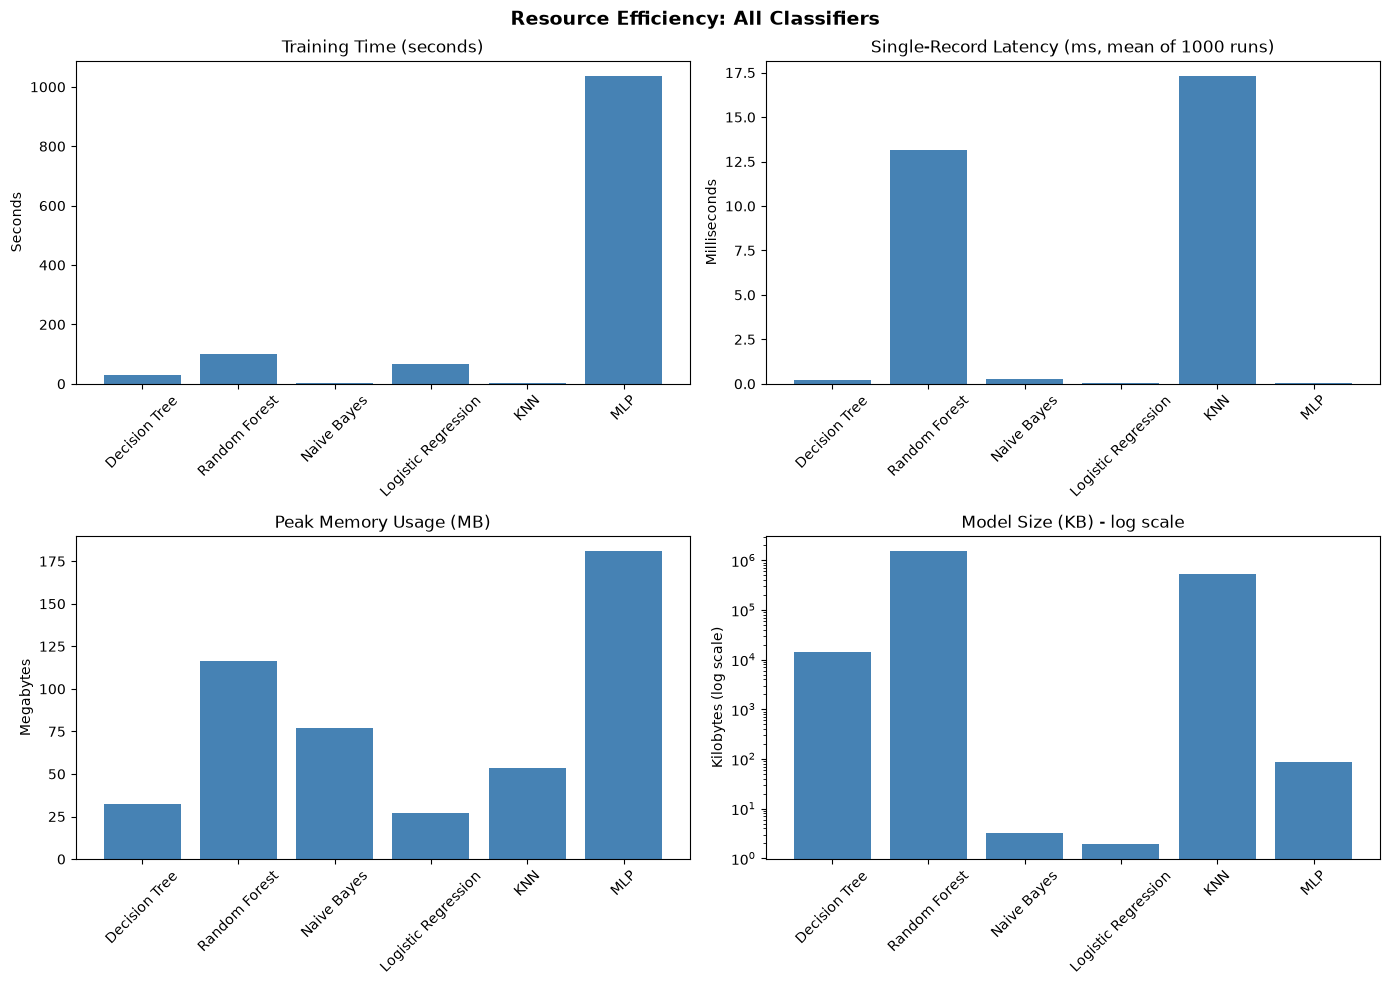

Chart saved.


In [10]:
# Resource efficiency charts.
# Four separate bar charts, one per metric.
# The inference panel shows single-record latency, the measurement
# that reflects real-time detection on an IoT device. 
# Total batch time and throughput are reported in the results table.
# These figures are in the report implementation/results chapter.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Resource Efficiency: All Classifiers', fontsize=14, fontweight='bold')

classifiers_names = df_resources['Classifier']

# Training time
axes[0, 0].bar(classifiers_names, df_resources['Training Time (s)'], color='steelblue')
axes[0, 0].set_title('Training Time (seconds)')
axes[0, 0].set_ylabel('Seconds')
axes[0, 0].tick_params(axis='x', rotation=45)

# Single-record latency (real-time detection)
axes[0, 1].bar(classifiers_names, df_resources['Latency mean (ms)'], color='steelblue')
axes[0, 1].set_title('Single-Record Latency (ms, mean of 1000 runs)')
axes[0, 1].set_ylabel('Milliseconds')
axes[0, 1].tick_params(axis='x', rotation=45)

# Memory usage
axes[1, 0].bar(classifiers_names, df_resources['Memory Usage (MB)'], color='steelblue')
axes[1, 0].set_title('Peak Memory Usage (MB)')
axes[1, 0].set_ylabel('Megabytes')
axes[1, 0].tick_params(axis='x', rotation=45)

# Model size - use log scale because Random Forest dwarfs everything
axes[1, 1].bar(classifiers_names, df_resources['Model Size (KB)'], color='steelblue')
axes[1, 1].set_title('Model Size (KB) - log scale')
axes[1, 1].set_ylabel('Kilobytes (log scale)')
axes[1, 1].set_yscale('log')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "chart_resource_efficiency.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

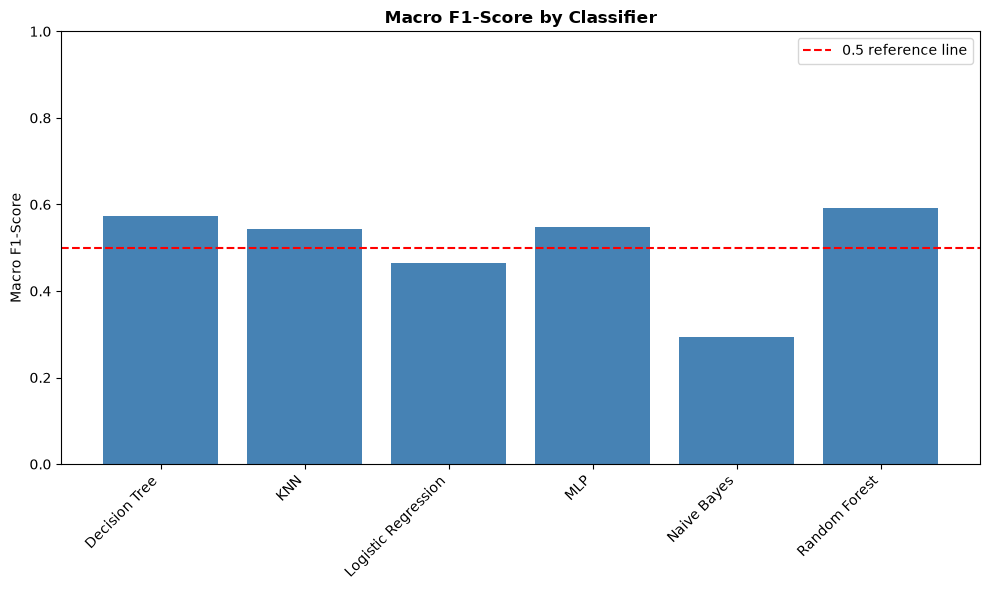

Chart saved.


In [11]:
# Macro F1-score comparison chart.
# Macro F1 is the primary accuracy metric for this project because
# it treats all attack categories equally regardless of class size.

macro_f1 = df_accuracy.groupby('Classifier')['F1-Score'].mean().reset_index()
macro_f1.columns = ['Classifier', 'Macro F1']

plt.figure(figsize=(10, 6))
plt.bar(macro_f1['Classifier'], macro_f1['Macro F1'], color='steelblue')
plt.title('Macro F1-Score by Classifier', fontweight='bold')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1)
plt.axhline(y=0.5, color='red', linestyle='--', label='0.5 reference line')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "chart_macro_f1.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

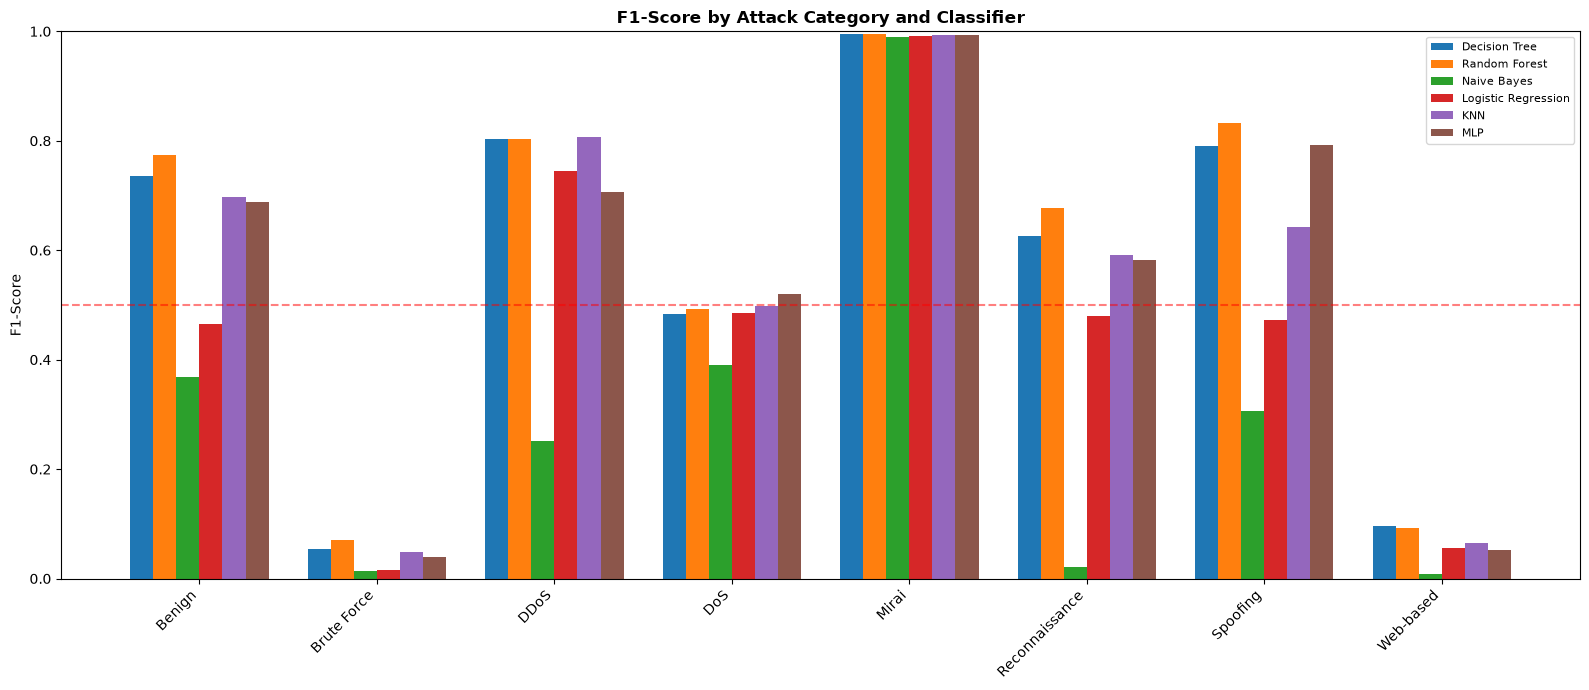

Chart saved.


In [12]:
# Per-category F1-score chart showing how each classifier performs
# across all seven attack categories + Benign.
# This is the most detailed accuracy chart and shows where each
# classifier struggles (Brute Force, Web-based) vs excels (Mirai).

categories = sorted(df_accuracy['Attack Category'].unique())
classifiers_list = df_accuracy['Classifier'].unique()

x = np.arange(len(categories))
width = 0.13

fig, ax = plt.subplots(figsize=(16, 7))

for i, clf_name in enumerate(classifiers_list):
    subset = df_accuracy[df_accuracy['Classifier'] == clf_name]
    subset = subset.set_index('Attack Category').reindex(categories)
    ax.bar(x + i * width, subset['F1-Score'], width, label=clf_name)

ax.set_title('F1-Score by Attack Category and Classifier', fontweight='bold')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.legend(loc='upper right', fontsize=8)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "chart_f1_by_category.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

---
## Ranking stability: cross-validation of the two top models

The main results above come from a single 70/30 train/test split, on
which Random Forest (macro F1 0.59) outranks Decision Tree
(0.57). To test whether this 0.02 gap is stable, 5-fold stratified cross-validation is applied to the two
top-ranked models.

Repeated stratified holdouts and bootstrap confidence intervals would
answer the same question. Cross-validation is used here as the standard
approach. The check is applied to Decision Tree and Random Forest only,
as these are the two models whose ordering is in question. The slower
baselines are not cross-validated, as this is unnecessary for the
ranking question and is computationally expensive (KNN in particular).

SMOTE-ENN is applied inside each fold, on that fold's training portion
only, using an imbalanced-learn Pipeline. This prevents synthetic
samples from leaking into the validation fold. Cross-validation
therefore uses the pre-SMOTE training data (X_train_unresampled) saved
in Notebook 02, not the already-resampled data.

In [13]:
# Cross-validation for the two top models: Decision Tree and Random Forest.
# We split the data into 5 folds and test each model 5 times, then repeat
# the whole thing 3 times. That gives 15 scores per model. More scores
# make the comparison more reliable.
#
# SMOTE-ENN is applied inside each fold, on the training part only. This
# stops synthetic data leaking into the part we test on.
#
# Speed setting: the folds run across all cores, and Random Forest inside
# runs on one core. This is faster here and uses less memory.

from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN

# Load the pre-SMOTE training data saved by Notebook 02.
X_cv = joblib.load(OUTPUT_DIR + "X_train_unresampled.pkl")
y_cv = joblib.load(OUTPUT_DIR + "y_train_unresampled.pkl")

print(f"Cross-validation data: {X_cv.shape}")
print("Running 5-fold cross-validation, repeated 3 times (15 fits per model).")
print("This is the slow cell. Expect a few minutes.\n")

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

# Both models ignore feature scale, so no scaler is needed here.
# Random Forest runs on one core on purpose (see the speed setting note above).
cv_models = {
    "Decision Tree": DecisionTreeClassifier(
        criterion="gini", max_depth=None, min_samples_split=2,
        min_samples_leaf=1, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, criterion="gini", max_depth=None,
        max_features="sqrt", random_state=RANDOM_STATE, n_jobs=1
    ),
}

cv_scores = {}   # full set of fold scores, kept for the paired test
cv_results = []

for model_name, model in cv_models.items():
    pipeline = ImbPipeline(steps=[
        ("smote_enn", SMOTEENN(random_state=RANDOM_STATE)),
        ("classifier", model),
    ])

    scores = cross_val_score(
        pipeline, X_cv, y_cv,
        cv=cv, scoring="f1_macro", n_jobs=-1
    )

    cv_scores[model_name] = scores

    print(f"{model_name}")
    print(f"  {len(scores)} fold scores, "
          f"mean {scores.mean():.4f}, std {scores.std():.4f}\n")

    cv_results.append({
        "Classifier": model_name,
        "CV Mean Macro F1": round(scores.mean(), 4),
        "CV Std Macro F1": round(scores.std(), 4),
        "CV N Scores": len(scores),
    })

df_cv = pd.DataFrame(cv_results)
df_cv.to_csv(OUTPUT_DIR + "results_cross_validation.csv", index=False)

# Save the raw fold scores. This allows us to redo the statistics later
# without running this slow cell again.
cv_scores_df = pd.DataFrame(cv_scores)
cv_scores_df.to_csv(OUTPUT_DIR + "results_cv_fold_scores.csv", index=False)

print("Saved results_cross_validation.csv and results_cv_fold_scores.csv")
print(df_cv.to_string(index=False))

Cross-validation data: (511843, 13)
Running 5-fold cross-validation, repeated 3 times (15 fits per model).
This is the slow cell. Expect a few minutes.

Decision Tree
  15 fold scores, mean 0.5679, std 0.0056

Random Forest
  15 fold scores, mean 0.5902, std 0.0072

Saved results_cross_validation.csv and results_cv_fold_scores.csv
   Classifier  CV Mean Macro F1  CV Std Macro F1  CV N Scores
Decision Tree            0.5679           0.0056           15
Random Forest            0.5902           0.0072           15


---
## Lightweight checks
 

In [14]:
# Lightweight checks: confirm every classifier trained and produced valid output.

assert X_train.shape[0] == len(y_train), "Training data shape mismatch"
assert X_test.shape[0] == len(y_test), "Test data shape mismatch"
assert len(resource_results) == 6, f"Expected 6 classifiers evaluated, got {len(resource_results)}"

for name, y_pred in all_predictions.items():
    assert len(y_pred) == len(y_test), f"{name}: prediction count does not match test set size"

print("All checks passed.")

All checks passed.


---
## Summary


In [15]:
print(f"{'Step':<10} {'Description':<52} {'Result'}")
print("-" * 105)
print(f"{'Load':<10} {'Preprocessed data loaded from Notebook 02':<52} {len(X_train):,} training, {len(X_test):,} test, {X_test.shape[1]} features")
print(f"{'Train':<10} {'Six classifiers, explicit hyperparameters, seed 42':<52} scaled data for LR, KNN, MLP; unscaled for DT, RF, NB")
print(f"{'Evaluate':<10} {'Resource efficiency and accuracy measured':<52} {len(resource_results)} classifiers, batch and single-record timing")
print(f"{'Stability':<10} {'5-fold cross-validation of the two top models':<52} DT and RF, SMOTE-ENN applied inside each fold")
print(f"{'Save':<10} {'Results written to CSV':<52} accuracy, resources and cross-validation files")

Step       Description                                          Result
---------------------------------------------------------------------------------------------------------
Load       Preprocessed data loaded from Notebook 02            2,273,555 training, 219,362 test, 13 features
Train      Six classifiers, explicit hyperparameters, seed 42   scaled data for LR, KNN, MLP; unscaled for DT, RF, NB
Evaluate   Resource efficiency and accuracy measured            6 classifiers, batch and single-record timing
Stability  5-fold cross-validation of the two top models        DT and RF, SMOTE-ENN applied inside each fold
Save       Results written to CSV                               accuracy, resources and cross-validation files


### Strongest candidate for IoT deployment

Decision Tree is described as the strongest candidate for deployment
testing on Linux-capable edge devices, based on its trade-off between
detection accuracy and resource efficiency. It is not claimed as proven
suitable, because all experiments were run on a MacBook Air, and not
on IoT hardware.

The figures below are read directly from the saved results files, so
they always reflect the most recent run.

In [16]:
# Deployment summary with real numbers read from the saved results files,
# plus the proper paired statistics for the stability check.

from scipy import stats

df_res = pd.read_csv(OUTPUT_DIR + "results_resources.csv")
df_acc = pd.read_csv(OUTPUT_DIR + "results_accuracy.csv")
df_cv  = pd.read_csv(OUTPUT_DIR + "results_cross_validation.csv")
fold_scores = pd.read_csv(OUTPUT_DIR + "results_cv_fold_scores.csv")

macro_f1 = df_acc.groupby("Classifier")["F1-Score"].mean()

def resource_value(clf_name, column):
    return df_res.loc[df_res["Classifier"] == clf_name, column].iloc[0]

dt_f1 = macro_f1["Decision Tree"]
rf_f1 = macro_f1["Random Forest"]
dt_size = resource_value("Decision Tree", "Model Size (KB)")
rf_size = resource_value("Random Forest", "Model Size (KB)")
dt_latency = resource_value("Decision Tree", "Latency mean (ms)")

print("STRONGEST CANDIDATE FOR IOT DEPLOYMENT")
print("=" * 60)
print(f"Decision Tree: macro F1 {dt_f1:.4f}, "
      f"model size {dt_size:,.0f} KB, "
      f"single-record latency {dt_latency:.4f} ms")
print(f"Random Forest: macro F1 {rf_f1:.4f}, "
      f"model size {rf_size:,.0f} KB")
print()

# Paired comparison on the repeated cross-validation fold scores.
# The two models were evaluated on identical folds, so the scores pair
# up fold by fold. We report the mean difference, its 95% confidence
# interval, and a paired t-test p-value.
dt_scores = fold_scores["Decision Tree"].values
rf_scores = fold_scores["Random Forest"].values
diff = rf_scores - dt_scores          # positive means RF ahead
n = len(diff)

mean_diff = diff.mean()
# Standard error of the mean difference, and 95% CI using the t distribution.
sem = stats.sem(diff)
ci_low, ci_high = stats.t.interval(0.95, df=n - 1, loc=mean_diff, scale=sem)
t_stat, p_value = stats.ttest_rel(rf_scores, dt_scores)

print("RANKING STABILITY (repeated 5-fold cross-validation)")
print("=" * 60)
print(f"Decision Tree: mean macro F1 {dt_scores.mean():.4f} "
      f"(std {dt_scores.std():.4f}, n={n})")
print(f"Random Forest: mean macro F1 {rf_scores.mean():.4f} "
      f"(std {rf_scores.std():.4f}, n={n})")
print()
print(f"Mean difference (RF - DT): {mean_diff:.4f}")
print(f"95% confidence interval:   [{ci_low:.4f}, {ci_high:.4f}]")
print(f"Paired t-test p-value:     {p_value:.4f}")
print()

if ci_low <= 0 <= ci_high:
    print("The 95% CI for the difference includes zero, and so the")
    print("RF vs DT ranking is NOT statistically stable: the gap could")
    print("plausibly be zero. Report the two models as effectively tied.")
else:
    print("The 95% CI for the difference excludes zero, so the ranking")
    print("is statistically stable in the direction shown above.")

STRONGEST CANDIDATE FOR IOT DEPLOYMENT
Decision Tree: macro F1 0.5727, model size 14,392 KB, single-record latency 0.2042 ms
Random Forest: macro F1 0.5922, model size 1,557,179 KB

RANKING STABILITY (repeated 5-fold cross-validation)
Decision Tree: mean macro F1 0.5679 (std 0.0056, n=15)
Random Forest: mean macro F1 0.5902 (std 0.0072, n=15)

Mean difference (RF - DT): 0.0223
95% confidence interval:   [0.0186, 0.0260]
Paired t-test p-value:     0.0000

The 95% CI for the difference excludes zero, so the ranking
is statistically stable in the direction shown above.
